## Points to improve
- dry dates should be taken from the attributes of the shapefile.
- processed images (tile) should be stored in a json file.
- flood map tiles have a gap in between. Polygon dissolve will leave gap.
- store polygon-wise cell-level mean and std values or all values in the dry period? If doing the first option, how to update with new images? No need to update for IFMIAP and have a static cell-level mean and std values?
- make a class object for mapping floods and push everything in the backend.
- using dry period, process every new image that comes in.
- ~flood maps are vertically flipped~

## Interesting points
- The read_reproject function processed 84 scenes in 9 min 28 sec on local computer at overview level 3.

In [8]:
# import required libraries
from ifmiap import utils
from ifmiap import authenticate
from ifmiap import preprocessing
from ifmiap import mapfloods
from ifmiap import postprocessing
import datetime
import pandas as pd
#from shapely.affinity import translate
from matplotlib import pyplot as plt

In [2]:
%%time
# process certain squares using a list of grid IDs
selected_grid_id = [190, 104]#[189, 190, 104, 161, 61, 59]
aoi_union = utils.gpd_to_json(id_list=selected_grid_id, separate=False) # this is for searching scenes
aoi_list = utils.gpd_to_json(id_list=selected_grid_id, separate=True) # this is to seggregate the search


# define the flood date range
pre_flood_dates = utils.date_range('01/05/2020', 60)
post_flood_dates = utils.date_range('20/07/2020', 8)


# the below function can take GDF directly, that it can filter using id and 
# pre and post flood dates can be pulled from the scene itself.
# Doing so will push a lot of the code above to the backend.
# pull sentinel-1 images for pre and post flood duration
pre_s1_scenes = {aoi['properties']['ID']: 
                 utils.search_sentinel_data(
                     bbox = aoi, 
                     start_date = pre_flood_dates[0], 
                     end_date = pre_flood_dates[-1]
                 )
                 for aoi in aoi_union
                }

post_s1_scenes = {aoi['properties']['ID']: 
                 utils.search_sentinel_data(
                     bbox = aoi, 
                     start_date = post_flood_dates[0], 
                     end_date = post_flood_dates[-1]
                 )
                 for aoi in aoi_union
                }

# run this only if the search was performed on the union of AOI
pre_aoi_scene_dict, pre_scene_aoi_dict = utils.seggregate_sentinel_search(aoi_list, pre_s1_scenes)
post_aoi_scene_dict, post_scene_aoi_dict = utils.seggregate_sentinel_search(aoi_list, post_s1_scenes)

# convert s1_scenes dictionary to list
pre_s1_scenes = [item for item in list(pre_s1_scenes.values())[0]]
post_s1_scenes = [item for item in list(post_s1_scenes.values())[0]]

for id in pre_aoi_scene_dict:
    print(f'ID: {id}, {len(pre_aoi_scene_dict[id])} pre flood scenes and {len(post_aoi_scene_dict[id])} post flood scenes found.')

ID: 104, 35 pre flood scenes and 7 post flood scenes found.
ID: 190, 25 pre flood scenes and 4 post flood scenes found.
CPU times: user 352 ms, sys: 29.5 ms, total: 381 ms
Wall time: 1.66 s


In [3]:
%%time
# read and reproject the images all at once, not separately for each tile
reprojected_pre_combined = {
    stac_id: stac_ds
    for item in pre_s1_scenes
    for (stac_id, stac_ds) in [preprocessing.read_reproject(item)]
}

reprojected_post_combined = {
    stac_id: stac_ds
    for item in post_s1_scenes
    for (stac_id, stac_ds) in [preprocessing.read_reproject(item)]
}

CPU times: user 17.8 s, sys: 2.92 s, total: 20.7 s
Wall time: 6min 39s


In [4]:
%%time
# separate and clip the reprojected image for each tile
reprojected_clipped_pre = {
    id: preprocessing.clip_stac(reprojected_pre_combined, pre_aoi_scene_dict, id)
    for id in selected_grid_id
}

reprojected_clipped_post = {
    id: preprocessing.clip_stac(reprojected_post_combined, post_aoi_scene_dict, id)
    for id in selected_grid_id
}

CPU times: user 2.95 s, sys: 208 ms, total: 3.16 s
Wall time: 3.17 s


In [5]:
%%time
# stack the reprojected and clipped images
stacked_pre = {f'{id}':
                preprocessing.stack_images(reprojected_clipped_pre[id], id)
                for id in reprojected_clipped_pre
               }
stacked_post = {f'{id}':
                preprocessing.stack_images(reprojected_clipped_post[id], id)
                for id in reprojected_clipped_post
               }

# match the cell size and extent of post image stack to the extent of pre stack
for id in stacked_pre:
    stacked_post[id]['vv_stack'] = stacked_post[id]['vv_stack'].rio.reproject_match(stacked_pre[id]['vv_stack']).rio.write_transform(stacked_pre[id]['vv_stack'].rio.transform())
    stacked_post[id]['vh_stack'] = stacked_post[id]['vh_stack'].rio.reproject_match(stacked_pre[id]['vh_stack']).rio.write_transform(stacked_pre[id]['vh_stack'].rio.transform())

CPU times: user 1.18 s, sys: 163 ms, total: 1.34 s
Wall time: 1.39 s


/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


CPU times: user 969 ms, sys: 146 ms, total: 1.12 s
Wall time: 1.13 s


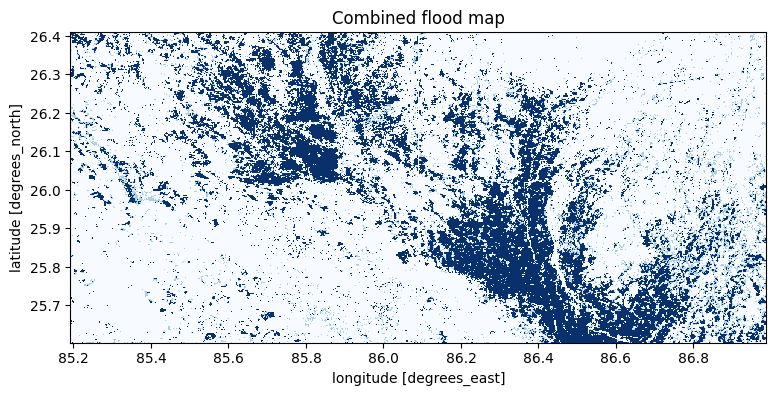

In [6]:
%%time
vv_thd = 2.5
vh_thd = 2.5

# generate the flood rasters
flood_dict = {f'{id}':
              mapfloods.anomaly_cells(stacked_pre[f'{id}'], stacked_post[f'{id}'], vv_thd, vh_thd)
              for id in selected_grid_id
             }


# export the flood rasters
for id in flood_dict:
    outfile_flood = f'/Users/pratyusht/Documents/MapSolveAI/ifmiap/output/FloodExtent{id}.tif'

    utils.export_xarray(flood_dict[id], outfile_flood)
    

x_min = min(flood_dict[id].x.min() for id in flood_dict)
y_min = min(flood_dict[id].y.min() for id in flood_dict)
x_max = max(flood_dict[id].x.max() for id in flood_dict)
y_max = max(flood_dict[id].y.max() for id in flood_dict)

# export an image of the combined flood rasters
fig, ax = plt.subplots(1, 1, figsize=((x_max - x_min)*5, (y_max - y_min)*5))

for id in flood_dict:
    img = flood_dict[id].plot(ax=ax, cmap='Blues')
    img.colorbar.remove()

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title('Combined flood map')
    
plt.savefig(outfile_flood.replace('.tif', '.png'), bbox_inches='tight', dpi=100)

In [31]:
%%time

import rioxarray
import rasterio.features
from shapely.geometry import shape
import geopandas as gpd
from shapely.geometry import box
import pandas as pd

def polygonize_flood_raster(flood_data):
    data = flood_data.astype('uint8')
    shapes_gen = rasterio.features.shapes(data.values, mask=data.values != 0, transform=data.rio.transform())
    polygons = [shape(geom) for geom, value in shapes_gen if value == 3]  # Adjust the condition as needed

    # create a GPD GDF from the polygons
    gdf = gpd.GeoDataFrame({'geometry': polygons})

    # assign a CRS (Coordinate Reference System) to the GDF
    gdf.crs = data.rio.crs.to_string()

    """
    extend the polygons at the edges because there is gap between tiles
    """
    # get the cell size from the raster layer
    cell_size = float(flood_data.spatial_ref.GeoTransform.split(' ')[1])

    # buffer the polygons
    gdf_buffer = gdf.buffer(cell_size * 1.5)

    # extract tht total extent of GDF as a GDF
    gdf_extent = box(*gdf.total_bounds)

    # create buffer of the polygon layer and dissolve it
    gdf_buffer = pd.concat([
        gpd.GeoDataFrame(geometry=gdf_buffer, crs=gdf.crs),
        gpd.GeoDataFrame(geometry=[gdf_extent])
    ], axis=0).dissolve()

    
    # perform spatial difference of the buffer and the total extent
    gdf_extra = gdf_buffer.symmetric_difference(gdf_extent)

    
    # merge the extra part with the original GDF
    gdf = pd.concat([
        gdf, gpd.GeoDataFrame(geometry=gdf_extra, crs=gdf.crs)
    ], axis=0)
    
    return gdf

flood_polygon = pd.concat(
    [
        polygonize_flood_raster(flood_dict[id])
        for id in flood_dict
    ], axis=0)

#delta_y = flood_polygon.total_bounds[-1] - flood_polygon.total_bounds[1]
#flood_polygon['geometry'] = flood_polygon['geometry'].apply(lambda geom: translate(geom, xoff=0, yoff=delta_y))

flood_polygon.to_file(f'/Users/pratyusht/Documents/MapSolveAI/ifmiap/output/FloodExtent.gpkg', index=False)

<timed exec>:26: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/opt/homebrew/lib/python3.9/site-packages/geopandas/array.py:1486: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  warnings.warn(
<timed exec>:26: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/opt/homebrew/lib/python3.9/site-packages/geopandas/array.py:1486: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  warnings.warn(


CPU times: user 4.1 s, sys: 62.8 ms, total: 4.16 s
Wall time: 4.17 s
